In [1]:
%matplotlib inline
import ssl
ssl._create_default_https_context = ssl._create_unverified_context
import numpy as np
from simulator import AnalogCore, CrossSimParameters
from simulator import CrossSimParameters
from simulator.backend import ComputeBackend
import scipy.linalg
import matplotlib
import matplotlib.pyplot as plt
import pickle
from PIL import Image
np.random.seed(498)

# Convert to decibels relative to full scale (dBFS)
def dbfs_rgb(x):
    maxVal = np.max(x)
    db_R = 20*np.log10((x[:,:,0] + np.finfo(float).eps)/maxVal)
    db_G = 20*np.log10((x[:,:,1] + np.finfo(float).eps)/maxVal)
    db_B = 20*np.log10((x[:,:,2] + np.finfo(float).eps)/maxVal)
    return [db_R, db_G, db_B]

# Application co-design with CrossSim

In this notebook, we will show some examples of how we can use CrossSim to evaluate the accuracy of analog processing-using-memory (PUM) on some applications. We will start with the Fourier transform application (Part 1) then evaluate on a neural network application (Part 2).

# Part 1: Discrete Fourier transform (DFT)

## 1.1: Problem setup

The DFT is an operation that is used ubiquitously for many applications. Here, we will demonstrate a 2D DFT which is a crucial component of many image processing workloads. It also has the nice advantage of allowing us to see the effects of simulated errors induced by analog PUM directly as visual artifacts in an image.

First, we will load the "Ichiro" image that will be used for this analysis.

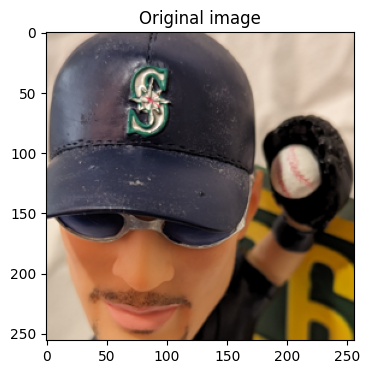

In [2]:
# Load image
N, N, Nch = 256, 256, 3
ichiro = Image.open('../../applications/dsp/example_images/ichiro.jpg').resize((N,N))
ichiro = np.array(ichiro).astype(np.float32) / 255

# Show image
fig,ax = plt.subplots(1,1,figsize=(4,4))
ax.imshow(ichiro)
ax.set_title("Original image")
plt.show()

For a square $N \times N$ image, the 2D DFT operation is defined by the following equation:

$Y_{j,k} = \sum \limits_{m=0}^{N-1} \sum \limits_{n=0}^{N-1} Y_{m,n} \exp{\left(-i\frac{2\pi}{N}kn\right)} \exp{\left(-i\frac{2\pi}{N}jm\right)}$

Using row-column decomposition, the 2D DFT can be written as two matrix-matrix multiplications applied on the input image:

$\mathbf{Y} = \mathbf{W}_N\mathbf{X}\mathbf{W}_N^T$

where $\mathbf{W}_N$ is the $N$-point DFT matrix, and $\mathbf{X}$ and $\mathbf{Y}$ are the 2D input and output.

After computing the 2D DFT, we can get back the original image by applying the 2D inverse DFT to the computed spectrum. The inverse DFT is evaluated using the same expression as above, but its matrix is the conjugate transpose: $\mathbf{W}_N^H$.

Let's first implement this using NumPy.

In [3]:
# First, create the matrices for the DFT and inverse DFT
W_dft = scipy.linalg.dft(N)
W_idft = np.matrix.getH(W_dft)

# Container for the 2D spectrum and reconstruction
spectrum = np.zeros(ichiro.shape, dtype=np.complex128)
reconstruction = np.zeros(ichiro.shape, dtype=np.complex128)

for ch in range(Nch):

    # Compute 2D DFT
    partial_dft = W_dft @ ichiro[:,:,ch]
    spectrum[:,:,ch] = partial_dft @ W_dft

    # Compute 2D inverse DFT
    partial_idft = W_idft @ spectrum[:,:,ch]
    reconstruction[:,:,ch] = partial_idft @ W_idft

Now let's visualize the computed spectrum and the reconstructed image.

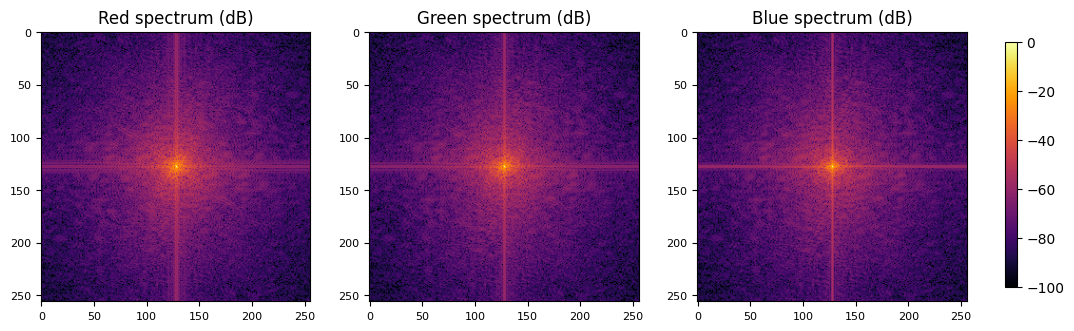

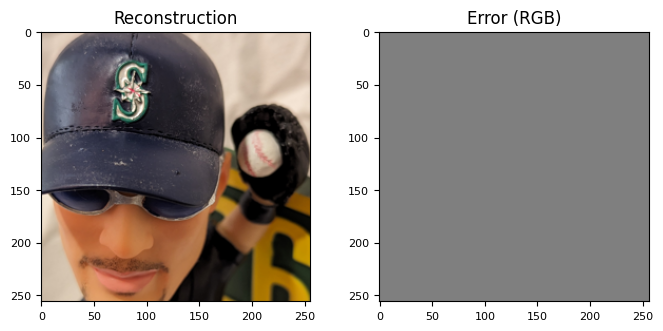

In [4]:
# Express each channel's magnitude spectrum as dBFS (decibels relative to full scale)
mag_spectrum = np.abs(spectrum)
dB_spectrum = dbfs_rgb(mag_spectrum)

# Plot the computed frequency spectrum for each color
fig,axes = plt.subplots(1,3,figsize=(12,3.5))
cmap = matplotlib.colormaps["inferno"]
colors = ["Red","Green","Blue"]
C=[axes[j].imshow(np.fft.fftshift(dB_spectrum[j]), vmin=-100, vmax=0, cmap=cmap) for j in range(3)]
[axes[j].set_title(colors[j]+" spectrum (dB)") for j in range(3)]
fig.subplots_adjust(right=0.9)
cbar_ax = fig.add_axes([0.93, 0.15, 0.01, 0.7])
cbar = fig.colorbar(C[0], cax=cbar_ax)
[ax.tick_params(labelsize=8) for ax in axes]

# Plot the reconstructed image
reconstruction = np.abs(reconstruction)/np.max(np.abs(reconstruction))
error = reconstruction - ichiro + 0.5
fig2,axes2 = plt.subplots(1,2,figsize=(8,3.5))
axes2[0].imshow(reconstruction)
axes2[0].set_title("Reconstruction")
axes2[1].imshow(error)
axes2[1].set_title("Error (RGB)")
[ax.tick_params(labelsize=8) for ax in axes2]
plt.show()


## 1.2 Configuring and adding errors to the AnalogCore

Next, we'll make things more interesting by making our AnalogCore more physically realistic. We'll look directly at the conductances stored inside the core and see how errors in these conductances affect the quality of images we get using the 2D DFT.

__Negative number representation__: One of the first questions that comes up when we design an analog PUM system is: how do we map a matrix containing negative weights to a crossbar array where the conductances are purely positive? There are multiple ways to do this, but we'll focus here on differential cells, where each weight is encoded by the difference of two conductances.

<img src="./graphics/differential_cells.png" width=300 />

__Conductance programming errors__: The next major consideration is the random programming error in the conductance values. Specifically, how does the amount of random error depend on the conductance state $G$? This characteristic is different for every device, and CrossSim can support an arbitrarily complex, user-defined device error characteristic, as will be shown in the next tutorial.

To keep things simple, we will use one of two generic device error models that are incuded in CrossSim, both of which simulate programming error as a normally distributed random error $\mathcal{N}(0,\sigma_G)$ that is added to the conductance $G$. We will use the __state-proportional__ error model: $\sigma_G = \alpha*G$, where $\alpha$ controls the overall magnitude of the error.

<img src="./graphics/error_types.png" width=450 />

We will additionally give the following properties to the core:
- Memory device resistance range: 1 k$\Omega$ and 1M$\Omega$
- Bit precision of target weights: 8 bits

The first step is to create CrossSim parameter objects which capture the properties described above.

In [5]:
# Create a baseline error-free core that can hold a complex matrix
params_ideal = CrossSimParameters()
params_ideal.core.complex_input = True
params_ideal.core.complex_matrix = True
params_ideal.core.weight_bits = 8
params_ideal.xbar.device.Rmin - 1e3
params_ideal.xbar.device.Rmax = 1e6

# Create a copy of the baseline core and add device errors
params_alpha = params_ideal.copy()
params_alpha.xbar.device.programming_error.enable = True
params_alpha.xbar.device.programming_error.model = "NormalProportionalDevice"
params_alpha.xbar.device.programming_error.magnitude = 0.1

Next, we create AnalogCore objects using these parameters.

In [6]:
# Create AnalogCores and program DFT and inverse DFT matrix
xbar_dft_alpha = AnalogCore(W_dft, params = params_alpha)
xbar_idft_alpha = AnalogCore(W_idft, params = params_alpha)
xbar_dft_ideal = AnalogCore(W_dft, params = params_ideal)
xbar_idft_ideal = AnalogCore(W_idft, params = params_ideal)

Let's look under the hood at the crossbar of conductances that are used to store this matrix. Note that although we have plotted the positive and negative parts separately. The decomposition of the real and imaginary parts of the DFT matrix is handled automatically by CrossSim.

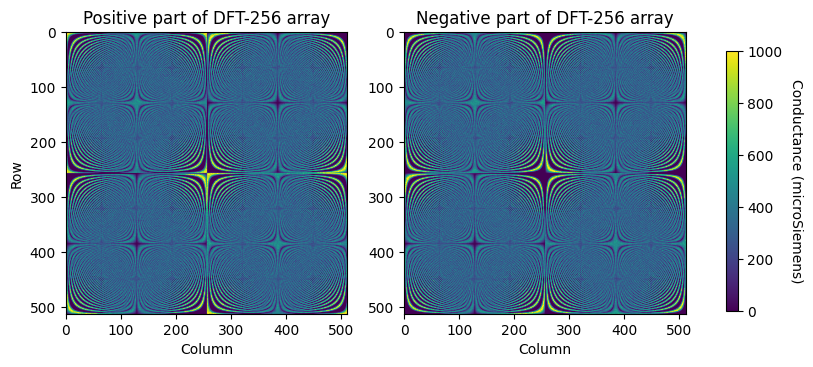

0 0
0 0
5.114766465736623e-07 0.0013788289443373855
5.546470415685827e-07 0.0014013444473498417


In [7]:
# Conductance arrays for non-ideal core
G_pos_alpha = xbar_dft_alpha.cores[0][0].core_pos.matrix / params_alpha.xbar.device.Rmin
G_neg_alpha = xbar_dft_alpha.cores[0][0].core_neg.matrix / params_alpha.xbar.device.Rmin

# Conductance arrays for ideal core
G_pos_ideal = xbar_dft_ideal.cores[0][0].core_pos.matrix / params_ideal.xbar.device.Rmin
G_neg_ideal = xbar_dft_ideal.cores[0][0].core_neg.matrix / params_ideal.xbar.device.Rmin

# Plot
fig,(ax1,ax2) = plt.subplots(1,2,figsize=(8,4))
C1=ax1.imshow(G_pos_alpha/1e-6, vmin=0, vmax=1e3)
ax2.imshow(G_neg_alpha/1e-6, vmin=0, vmax=1e3)
ax1.set_title("Positive part of DFT-256 array")
ax2.set_title("Negative part of DFT-256 array")
ax1.set_ylabel("Row")
[ax.set_xlabel("Column") for ax in [ax1,ax2]]
[ax.set_aspect("equal") for ax in [ax1,ax2]]
fig.subplots_adjust(right=0.9)
cbar_ax = fig.add_axes([0.95, 0.15, 0.015, 0.65])
cbar = fig.colorbar(C1, cax=cbar_ax)
cbar.set_label("Conductance (microSiemens)",rotation=270,labelpad=15)
plt.show()

print(np.isnan(G_pos_alpha).sum(), np.isinf(G_pos_alpha).sum())
print(np.isnan(G_neg_alpha).sum(), np.isinf(G_neg_alpha).sum())
print(np.nanmin(G_pos_alpha), np.nanmax(G_pos_alpha))
print(np.nanmin(G_neg_alpha), np.nanmax(G_neg_alpha))

This is a pretty large array, so let's just look at the top left corner of the positive array and compare to the ideal case.

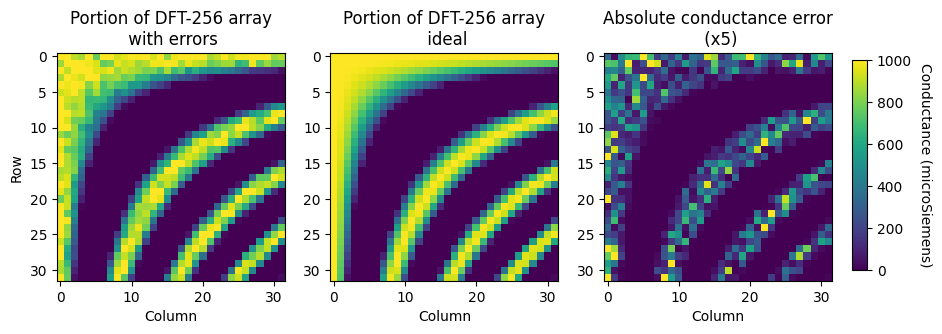

In [8]:
# Plot
fig, axes = plt.subplots(1,3,figsize=(10,3))
fig.subplots_adjust(right=0.9)
G_mats = [G_pos_alpha, G_pos_ideal, 5*np.abs(G_pos_alpha - G_pos_ideal)]
C = [axes[i].imshow(G_mats[i][:32,:32]/1e-6, vmin=0, vmax=1e3) for i in range(3)]
axes[0].set_title("Portion of DFT-256 array\n with errors",fontsize=12)
axes[1].set_title("Portion of DFT-256 array\n ideal",fontsize=12)
axes[2].set_title("Absolute conductance error\n (x5)")
axes[0].set_ylabel("Row")
[ax.set_xlabel("Column") for ax in axes]
[ax.set_aspect("equal") for ax in axes]
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
cbar = fig.colorbar(C[0], cax=cbar_ax)
cbar.set_label("Conductance (microSiemens)",rotation=270,labelpad=15)
plt.show()

Now let's simulate the 2D image reconstruction with analog PUM, using the DFT and inverse DFT arrays with conductance errors. This is done by using the same code we wrote to evaluate the 2D DFT with NumPy, and simply replacing the NumPy arrays with AnalogCores!

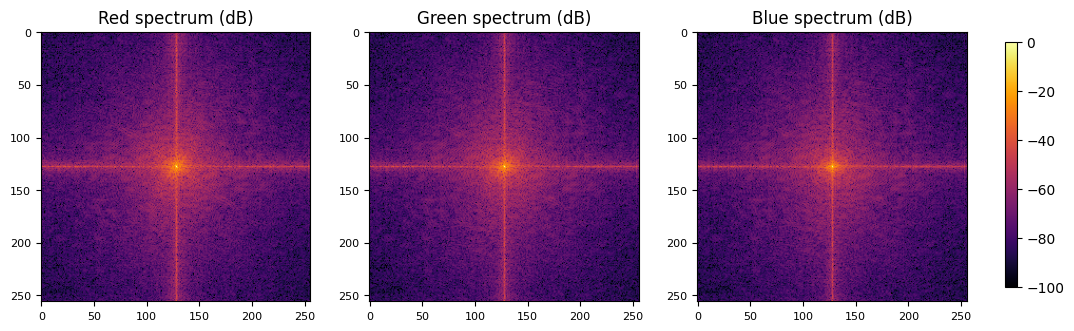

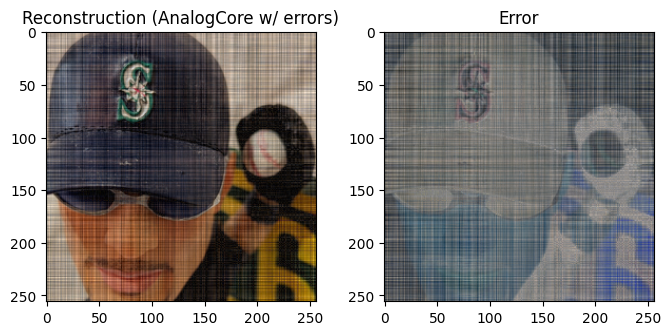

In [9]:
# Container for the 2D spectrum and reconstruction
spectrum_xbar = np.zeros(ichiro.shape, dtype=np.complex128)
reconstruction_xbar = np.zeros(ichiro.shape, dtype=np.complex128)

for ch in range(Nch):

    # Compute 2D DFT
    partial_dft = xbar_dft_alpha @ ichiro[:,:,ch]
    spectrum_xbar[:,:,ch] = partial_dft @ xbar_dft_alpha

    # Compute 2D inverse DFT
    partial_idft = xbar_idft_alpha @ spectrum_xbar[:,:,ch]
    reconstruction_xbar[:,:,ch] = partial_idft @ xbar_idft_alpha

# Express each channel's magnitude spectrum as dBFS (decibels relative to full scale)
mag_spectrum_xbar = np.abs(spectrum_xbar)
dB_spectrum_xbar = dbfs_rgb(mag_spectrum_xbar)

# Plot the spectrum
fig,axes = plt.subplots(1,3,figsize=(12,3.5))
cmap = matplotlib.colormaps["inferno"]
colors = ["Red","Green","Blue"]
C=[axes[j].imshow(np.fft.fftshift(dB_spectrum_xbar[j]), vmin=-100, vmax=0, cmap=cmap) for j in range(3)]
[axes[j].set_title(colors[j]+" spectrum (dB)") for j in range(3)]
fig.subplots_adjust(right=0.9)
cbar_ax = fig.add_axes([0.93, 0.15, 0.01, 0.7])
cbar = fig.colorbar(C[0], cax=cbar_ax)
[ax.tick_params(labelsize=8) for ax in axes]

# Plot the reconstructed image
reconstruction_xbar = np.abs(reconstruction_xbar)/np.max(np.abs(reconstruction_xbar))
error = reconstruction_xbar - ichiro + 0.5
fig,axes = plt.subplots(1,2,figsize=(8,3.5))
axes[0].imshow(reconstruction_xbar)
axes[0].set_title("Reconstruction (AnalogCore w/ errors)")
axes[1].imshow(error)
axes[1].set_title("Error")
[ax.tick_params(labelsize=8) for ax in axes2]
plt.show()

We see artifacts appearing in the reconstructed image because of the conductance errors. These artifacts are in the form of horizontal and vertical streaks because each column of weights in the DFT matrix contributes to one row or column of values in the matrix-matrix product. The same is true for the inverse DFT.

## 1.3 Weight bit slicing

Another design choice related to algorithm-to-hardware mapping is related to the representation of bit precision. In the previous examples, we encoded 8-bit weights in the state(s) of one or a pair of devices, which were assumed to have at least 128 target-able memory states.

We could also choose to split the bit precision across multiple devices, with fewer bits encoded per device. This is called bit slicing. In the example below, we use balanced core with four slices to represent 8-bit weights.

Below is a pictorial representation of bit slicing:
<br />
<br />


<img src="./graphics/bit_slicing.png" width=500 />

Note that in the scheme above, because each slice is made up of a pair of 2-bit devices, it actually encodes three bits: two magnitude bits and a sign bit. Taking the four slices together, we actually have the range to represent 9-bit weights: eight magnitude bits and a sign bit.

Let's create an AnalogCore with the same device properties as the example we used above, but uses bit slicing.

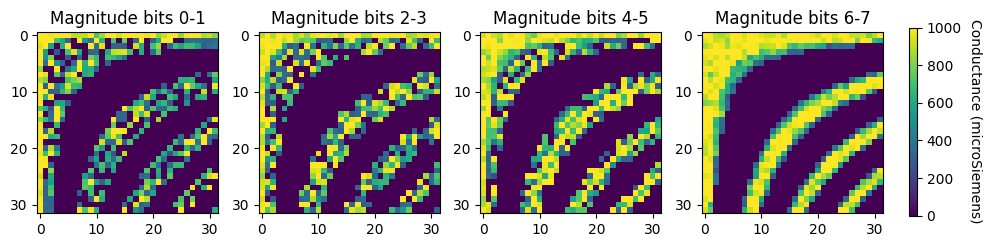

In [10]:
# Add bit slicing to our noisy parameters object
Nslices = 4
params_bitsliced = params_alpha.copy()
params_bitsliced.core.weight_bits = 9
params_bitsliced.core.bit_sliced.num_slices = Nslices
params_bitsliced.core.style = "BITSLICED"

xbar_dft_bitsliced = AnalogCore(W_dft, params = params_bitsliced)
xbar_idft_bitsliced = AnalogCore(W_idft, params = params_bitsliced)

# Get slice conductance matrices
G_slices = [None for i in range(Nslices)]
for i in range(Nslices):
    G_pos = xbar_dft_bitsliced.cores[0][0].core_slices[i][0].matrix / params_bitsliced.xbar.device.Rmin
    G_neg = xbar_dft_bitsliced.cores[0][0].core_slices[i][1].matrix / params_bitsliced.xbar.device.Rmin
    G_slices[i] = np.concatenate((G_pos, G_neg), axis=1)


# Plot
fig,axes = plt.subplots(1,4,figsize=(10.25,2.35))
plt.subplots_adjust(wspace=0.1)
C=[axes[i].imshow(G_slices[i][:32,:32]/1e-6, vmin=0, vmax=1e3) for i in range(4)]
[axes[i].set_title("Magnitude bits {:d}-{:d}".format(2*i,2*i+1), fontsize=12) for i in range(4)]
[axes[i].set_aspect("equal") for i in range(4)]
fig.subplots_adjust(right=0.97)
cbar_ax = fig.add_axes([0.985, 0.1, 0.008, 0.8])
cbar = fig.colorbar(C[0], cax=cbar_ax)
cbar.set_label("Conductance (microSiemens)",rotation=270,labelpad=15)
plt.show()

Let's see if the image reconstruction improves by using bit slicing with the same level of device conductance error.

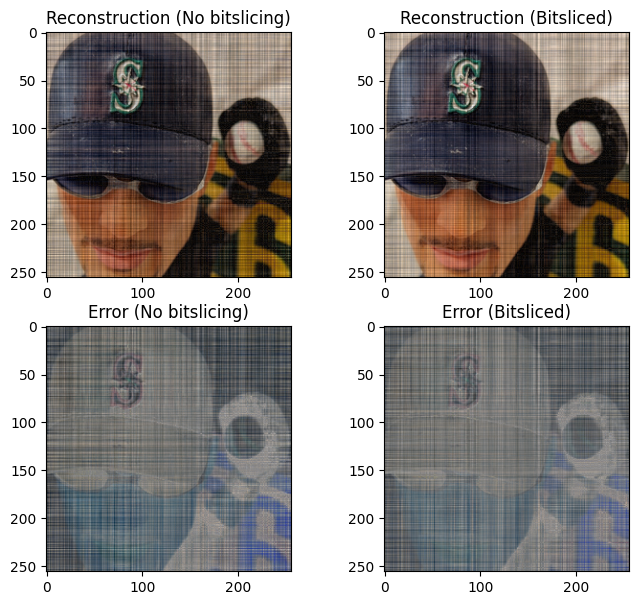

In [11]:
# Container for the 2D spectrum and reconstruction
reconstruction_xbar_bitsliced = np.zeros(ichiro.shape, dtype=np.complex128)

for ch in range(Nch):

    # Compute 2D DFT
    partial_dft = xbar_dft_bitsliced @ ichiro[:,:,ch]
    spectrum_ch = partial_dft @ xbar_dft_bitsliced

    # Compute 2D inverse DFT
    partial_idft = xbar_idft_bitsliced @ spectrum_ch
    reconstruction_xbar_bitsliced[:,:,ch] = partial_idft @ xbar_idft_bitsliced

# Plot the reconstructed image
reconstruction_xbar_bitsliced = np.abs(reconstruction_xbar_bitsliced)/np.max(np.abs(reconstruction_xbar_bitsliced))
error_bitsliced = reconstruction_xbar_bitsliced - ichiro + 0.5
fig,axes = plt.subplots(2,2,figsize=(8,7))
axes[0][0].imshow(reconstruction_xbar)
axes[0][0].set_title("Reconstruction (No bitslicing)")
axes[0][1].imshow(reconstruction_xbar_bitsliced)
axes[0][1].set_title("Reconstruction (Bitsliced)")
axes[1][0].imshow(error)
axes[1][0].set_title("Error (No bitslicing)")
axes[1][1].imshow(error_bitsliced)
axes[1][1].set_title("Error (Bitsliced)")
[ax.tick_params(labelsize=8) for ax in axes2]
plt.show()

## 1.4. Input quantization and analog-to-digital converter

Realistically, the analog PUM system needs to take digital inputs and produce digital outputs. We will specify the input numerical range and resolution, as well as the analog-to-digital converter (ADC) input current range and resolution.

We use an input range of (-1, +1) for each array. To account for the fact that each matmul in the 2D reconstruction has very different input ranges, we need to have a digital scaling/de-scaling step around each analog matmul. These scaling factors were roughly determined by inspecting the statistics of the inputs to each matmul.

We use ADCs with an input range of (-100, +100) in both the DFT and inverse DFT cores. These are normalized units in terms of the max current through a memory element. This was range was determined by a rough optimization process.

To keep things simpler, we will not use bit slicing.

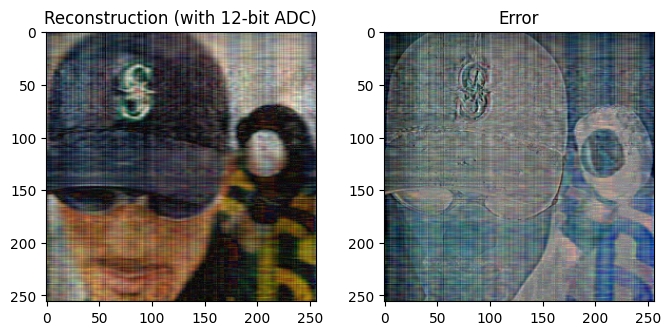

In [12]:
# # Add an ADC to our noisy parameters object 
params_adc = params_alpha.copy()
params_adc.xbar.adc.mvm.model = "SignMagnitudeADC"
params_adc.xbar.adc.mvm.bits = 12
params_adc.xbar.adc.mvm.calibrated_range = (-100, 100)
params_adc.xbar.dac.mvm.model = "SignMagnitudeDAC"
params_adc.xbar.dac.mvm.bits = 12
params_adc.core.mapping.inputs.mvm.min = -1
params_adc.core.mapping.inputs.mvm.max = 1

xbar_dft_adc = AnalogCore(W_dft, params = params_adc)
xbar_idft_adc = AnalogCore(W_idft, params = params_adc)

# Numerical ranges for the intermediate results, used to scale the inputs to the analog MVMs
range_partial_dft = 300
range_spectrum = 30000
range_partial_idft = 2

reconstruction_xbar = np.zeros(ichiro.shape, dtype=np.complex128)

for ch in range(Nch):

    # Compute 2D DFT
    partial_dft = xbar_dft_adc @ ichiro[:,:,ch]
    partial_dft /= range_partial_dft
    spectrum_ch = partial_dft @ xbar_dft_adc

    # Compute 2D inverse DFT
    spectrum_ch *= range_partial_dft/range_spectrum
    partial_idft = xbar_idft_adc @ spectrum_ch
    partial_dft *= range_spectrum/range_partial_idft
    reconstruction_xbar[:,:,ch] = partial_idft @ xbar_idft_adc
    partial_dft *= range_partial_idft

# Plot the reconstructed image
reconstruction_xbar = np.clip(np.abs(reconstruction_xbar)/np.max(np.abs(reconstruction_xbar)),0,1)
error = np.clip(reconstruction_xbar - ichiro + 0.5,0,1)
fig,axes = plt.subplots(1,2,figsize=(8,3.5))
axes[0].imshow(reconstruction_xbar)
axes[0].set_title("Reconstruction (with 12-bit ADC)")
C1=axes[1].imshow(error)
axes[1].set_title("Error")
[ax.tick_params(labelsize=8) for ax in axes2]
plt.show()

Note that including quantization and clipping has reduced the quality of the image noticeably, even with 12-bit resolution in both the inputs and ADCs! Although the input and ADC ranges could have been optimized more, it does indicate that this application has potentially higher requirements than neural networks. This comes from two things: (1) the DFT has continuous outputs rather than neural network models which may have discrete outputs (e.g. classification), so errors are more apparent, and (2) the DFT matrix is dense, while neural network weight matrices tend to be more sparse. This leads to higher precision requirements for the same matrix size.

# Part 2: Neural network inference

For the next demonstration we'll show that we can easily take a trained PyTorch model and simulate the accuracy of neural network inference when executed on analog PUM hardware. CrossSim automatically stores the weights as memory device conductances, which can include errors, and simulates the analog matrix-vector multiplications that are needed for an inference operation.

We will use a ResNet trained on CIFAR-10 for this demo. First, we will import PyTorch and other required modules.

In [13]:
from simulator.algorithms.dnn.torch.convert import from_torch, reinitialize, synchronize
import torch
from torchvision import datasets, transforms
from applications.dnn.torch.cifar10_resnet.build_resnet_cifar10 import ResNet_cifar10

Next, we will create a standard PyTorch DataLoader for the CIFAR-10 test set.

In [14]:
# Number of CIFAR-10 test images to use for this demo (max 10000)
N_images = 5000

# Inference batch size
batch_size = 64

# Transform for Gaussian normalization of the dataset
normalize = transforms.Normalize(
    mean = [0.485, 0.456, 0.406],
    std  = [0.229, 0.224, 0.225])

# Create data loader
dataset = datasets.CIFAR10(root='./',train=False, download=True, 
    transform= transforms.Compose([transforms.ToTensor(), normalize]))
dataset = torch.utils.data.Subset(dataset, np.arange(N_images))
cifar10_dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size)

Files already downloaded and verified


Now we will create the PyTorch model by passing a file containing the pre-trained weights into a standard PyTorch script that builds the ResNet. For this demo, we will use a ResNet-32.

In [15]:
resnet_model = ResNet_cifar10(2) # ResNet-32 has five residual blocks
resnet_model.load_state_dict(
    torch.load('../../applications/dnn/torch/cifar10_resnet/models/resnet14_cifar10.pth',
    map_location=torch.device('cuda')))
resnet_model = resnet_model.eval()

Now that we have our model and dataset, let's first run inference on it using PyTorch.

In [16]:
y_pred, y, k = np.zeros(N_images), np.zeros(N_images), 0
for inputs, labels in cifar10_dataloader:
    # Execute model
    output = resnet_model(inputs)
    # Collect outputs
    y_pred_k = output.data.detach().numpy()
    batch_size_k = y_pred_k.shape[0]
    y_pred[k:(k+batch_size_k)] = y_pred_k.argmax(axis=1)
    y[k:(k+batch_size_k)] = labels.detach().numpy()
    k += batch_size_k
    print("Image {:d}/{:d}, accuracy so far = {:.2f}%".format(
        k, N_images, 100*np.sum(y[:k] == y_pred[:k])/k), end="\r")

# Evaluate accuracy
top1 = np.sum(y == y_pred)/len(y)
print('Final accuracy: {:.2f}% ({:d}/{:d})\n'.format(top1*100,int(top1*N_images),N_images))

Final accuracy: 89.40% (4470/5000) 89.40%



Now let's see how this model would do with analog errors. For this, we'll import a set of AnalogCore hardware parameters that we've previously generated. This includes the mapping settings, device settings, and layer-specific input and ADC ranges. We will simulate inference with two custom device models: one for a ReRAM device (Milo et al, IRPS 2021) and one for a SONOS device (Agrawal et al, IEDM 2022). The two models are shown below:

<img src="./graphics/RRAM_SONOS.png" width=700 />

We'll load a list of parameters objects (one per layer) then look at the parameters for a layer in the middle of the network.

In [17]:
# Load all the parameters
params_list_RRAM = pickle.load(open("./params/resnet14_params_RRAMMilo.p","rb"))

xp = ComputeBackend()
xp._reset()
# Turn on GPU simulation
for p in params_list_RRAM:
    p.simulation.useGPU=True

# Show the parameters for layer 10
print(params_list_RRAM[10])

CrossSimParameters: 
{'core': {'balanced': {'interleaved_posneg': False,
                       'style': <BalancedCoreStyle.ONE_SIDED: 1>,
                       'subtract_current_in_xbar': True},
          'bit_sliced': {'num_slices': 2,
                         'style': <BitSlicedCoreStyle.BALANCED: 1>},
          'cols_max': 256,
          'complex_input': False,
          'complex_matrix': False,
          'mapping': {'inputs': {'_match': True,
                                 'mvm': {'clipping': False,
                                         'max': 7.751552602226406,
                                         'min': 0.0,
                                         'percentile': None},
                                 'vmm': {'clipping': False,
                                         'max': 7.751552602226406,
                                         'min': 0.0,
                                         'percentile': None}},
                      'weights': {'clipping': True,
          

In [18]:
# Convert the Conv2D and Linear layers in the PyTorch model to layers that use a CrossSim back-end
analog_resnet = from_torch(resnet_model.cuda(), params_list_RRAM, fuse_batchnorm=True)

# Print a summary of the new PyTorch model
print(analog_resnet)

ResNet_cifar10(
  (conv1): AnalogConv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): Identity()
  (relu): ReLU(inplace=True)
  (res1): Sequential(
    (0): BasicBlock(
      (conv1): AnalogConv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn1): Identity()
      (relu): ReLU(inplace=True)
      (conv2): AnalogConv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn2): Identity()
    )
    (1): BasicBlock(
      (conv1): AnalogConv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn1): Identity()
      (relu): ReLU(inplace=True)
      (conv2): AnalogConv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn2): Identity()
    )
  )
  (res2): Sequential(
    (0): BasicBlock(
      (conv1): AnalogConv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (bn1): Identity()
      (relu): ReLU(inplace=True)
      (conv2): AnalogConv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), paddi

In [19]:
y_pred, y, k = np.zeros(N_images), np.zeros(N_images), 0
for inputs, labels in cifar10_dataloader:
    # Execute model
    output = analog_resnet(inputs)
    # Collect outputs
    y_pred_k = output.data.detach().cpu().numpy()
    batch_size_k = y_pred_k.shape[0]
    y_pred[k:(k+batch_size_k)] = y_pred_k.argmax(axis=1)
    y[k:(k+batch_size_k)] = labels.detach().numpy()
    k += batch_size_k
    print("Image {:d}/{:d}, accuracy so far = {:.2f}%".format(
        k, N_images, 100*np.sum(y[:k] == y_pred[:k])/k), end="\r")

# Evaluate accuracy
top1 = np.sum(y == y_pred)/len(y)
print("\n=================")
print('Final accuracy: {:.2f}% ({:d}/{:d})\n'.format(top1*100,int(top1*N_images),N_images))

Image 5000/5000, accuracy so far = 65.36%
Final accuracy: 65.36% (3268/5000)



With this device error model, the CIFAR-10 inference accuracy experienced quite a large drop. This is partly because the RRAM device model has relatively large programming errors across its entire conductance range.

Now we'll run the same inference simulation but swap out the device to use the SONOS device, but otherwise keep all the other hardware assumptions the same.

In [20]:
# Load the parameter list with SONOS
params_list_SONOS = pickle.load(open("./params/resnet14_params_SONOS.p","rb"))

# Turn on GPU simulation
for p in params_list_SONOS:
    p.simulation.useGPU=True

# Create CrossSim-compatible PyTorch model with the new parameters
analog_resnet = from_torch(resnet_model, params_list_SONOS, fuse_batchnorm=True)

# Run simulation
y_pred, y, k = np.zeros(N_images), np.zeros(N_images), 0
for inputs, labels in cifar10_dataloader:
    # Execute model
    output = analog_resnet(inputs)
    # Collect outputs
    y_pred_k = output.data.detach().cpu().numpy()
    batch_size_k = y_pred_k.shape[0]
    y_pred[k:(k+batch_size_k)] = y_pred_k.argmax(axis=1)
    y[k:(k+batch_size_k)] = labels.detach().numpy()
    k += batch_size_k
    print("Image {:d}/{:d}, accuracy so far = {:.2f}%".format(
        k, N_images, 100*np.sum(y[:k] == y_pred[:k])/k), end="\r")

# Evaluate accuracy
top1 = np.sum(y == y_pred)/len(y)
print("\n=================")
print('Final accuracy: {:.2f}% ({:d}/{:d})\n'.format(top1*100,int(top1*N_images),N_images))

Image 5000/5000, accuracy so far = 88.56%
Final accuracy: 88.56% (4428/5000)

